# Replicating Kinney, Palmrose & Scholz (2004): Auditor Independence, Non-Audit Services, and Restatements
### U.S.E. Finance Data Hub / WRDS Database: **Audit Analytics**

**Paper replicated:** [Kinney, W. R., Palmrose, Z.-V. & Scholz, S. (2004). Auditor Independence, Non-Audit Services, and Restatements: Was the U.S. Government Right? *Journal of Accounting Research*, 42(3), 561–588.](https://doi.org/10.1111/j.1475-679X.2004.t01-1-00141.x)

**Database used:** [Audit Analytics](https://wrds-www.wharton.upenn.edu/pages/get-data/audit-analytics/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/audit-analytics/))

---

## What this notebook does

Kinney, Palmrose & Scholz (2004) investigate whether non-audit service (NAS) fees paid to audit firms are associated with a higher likelihood of financial restatements. The Sarbanes-Oxley Act of 2002 was passed partly on the presumption that such fees compromise auditor independence. The authors find mixed results: tax service fees are actually negatively associated with restatements (consistent with knowledge spillovers), while unspecified "other" NAS fees are positively associated with restatements.

Audit Analytics is the natural database for this analysis because it contains both audit fee data (`feed03_audit_fees`) and restatement data (`feed09_nonreliance_restatements`) for SEC registrants.

1. Pull audit fee data from **Audit Analytics** (`audit_audit_comp.feed03_audit_fees`) via the WRDS API
2. Pull restatement data from **Audit Analytics** (`audit_audit_comp.feed09_nonreliance_restatements`)
3. Merge the two datasets at the company-year level to create a binary restatement indicator
4. Examine the association between non-audit fee ratios and the probability of restatement
5. Compare our findings to the published 2004 results

## Learning objectives
- Practice connecting to WRDS and querying audit-related data from the Audit Analytics database
- Understand the structure of the two main Audit Analytics libraries (`audit_audit_comp` and `audit_common`)
- Learn how to link audit fee data with restatement data using company identifiers (`company_fkey`)
- Build intuition for how auditing research uses observational data to test questions about auditor independence

## Requirements to run this notebook
- A valid **WRDS account** with Audit Analytics access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn statsmodels`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the Audit Analytics variables we need

This replication uses two tables from the **`audit_audit_comp`** library.

**Audit Fees** (`feed03_audit_fees`) contains the fees paid by each SEC registrant to its auditor, broken down by service type.

| Paper concept | Description | Audit Analytics field |
|---|---|---|
| Company ID | SEC Central Index Key (CIK) | `company_fkey` |
| Fiscal Year | Fiscal year end | `fiscal_year` |
| Audit Fees | Fees for audit services | `audit_fees` |
| Audit-Related Fees | Fees for audit-related services | `audit_related` |
| Tax Fees | Fees for tax services | `tax_fees` |
| Other Fees | Fees for all other non-audit services | `other_fees` |
| Total Fees | Sum of all fees | `total_fees` |
| Auditor Name | Name of the audit firm | `auditor_name` |

**Non-Reliance Restatements** (`feed09_nonreliance_restatements`) contains material financial restatements (8-K Item 4.02 filings).

| Paper concept | Description | Audit Analytics field |
|---|---|---|
| Company ID | SEC CIK | `company_fkey` |
| Filing Date | Date the restatement was filed | `file_date` |
| Restatement Period Begin | Start of the restated period | `res_begin_date` |
| Restatement Period End | End of the restated period | `res_end_date` |
| Fraud Related | Whether the restatement involved fraud | `res_fraud` |

Both tables use `company_fkey` (the SEC CIK number) as the company identifier, which makes merging straightforward.


In [7]:
# Diagnostic: confirm the actual column names in feed03_audit_fees
cols = db.raw_sql("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'audit_audit_comp' AND table_name = 'feed03_audit_fees'
    ORDER BY ordinal_position
""")
print(cols["column_name"].tolist())

['auditor_fkey', 'audit_gig_key', 'fiscal_year', 'fiscal_year_ended', 'audit_fees', 'non_audit_fees', 'total_fees', 'benefits_fees', 'it_fees', 'tax_fees', 'tax_fees_compliance', 'tax_fees_non_compliance', 'audit_related_fees', 'other_fees', 'currency_code_fkey', 'restatement', 'auditor_name', 'fees_pcaob_reg', 'ftp_file_fkey', 'form_fkey', 'file_date', 'file_accepted', 'file_size', 'http_name_html', 'http_name_text', 'company_fkey', 'matchqu_price_date', 'matchqu_price_close', 'matchqu_tso_date', 'matchqu_tso', 'matchqu_tso_markcap', 'matchqu_date_qtr', 'matchqu_date_ttm', 'matchqu_filing_code_qtr', 'matchqu_filing_code_ttm', 'matchqu_annual_quindic', 'matchqu_balsh_book_val', 'matchqu_balsh_assets', 'matchqu_balsh_cash_equivs', 'matchqu_incmst_rev_qtr', 'matchqu_incmst_rev_ttm', 'matchqu_incmst_netinc_qtr', 'matchqu_incmst_netinc_ttm', 'matchqu_incmst_extraitm_qtr', 'matchqu_incmst_extraitm_ttm', 'matchqu_incmst_ebitda_qtr', 'matchqu_incmst_ebitda_ttm', 'matchqu_eff_accchange_qtr', '

In [9]:
# Diagnostic: "feed09_nonreliance_restatements" doesn't exist either -- list every table in audit_audit_comp so we can find the real name for the restatements feed.
tables = db.raw_sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'audit_audit_comp'
    ORDER BY table_name
""")
print(tables["table_name"].tolist())
print()
print("Likely candidates:")
print(tables[tables["table_name"].str.contains("restat|nonrel|feed09", case=False, regex=True)])

['f01_auditor_affiliate', 'f01_auditor_event', 'f01_auditor_event_to_auditor', 'f01_auditor_event_type', 'f01_auditor_location', 'f01_deleted_keys', 'f01_sec_locations', 'f02_deleted_keys', 'f03_deleted_keys', 'f04_deleted_keys', 'f06_deleted_keys', 'f06_form_ap_divided', 'f06_form_ap_filing', 'f06_form_ap_not_divided', 'f10_deleted_keys', 'f10_ic_dis_con_qua', 'f10_ic_dis_con_rea', 'f10_ic_qualifier', 'f10_ic_reason', 'f11_deleted_keys', 'f11_ic_opinion_qualifier', 'f11_ic_opinion_reason', 'f11_ic_qualifier', 'f11_ic_reason', 'f16_deleted_keys', 'f17_deleted_keys', 'f17_dno_change', 'f20_deleted_keys', 'f20_nt_fil_not_to_rea', 'f20_nt_filer_reason', 'f34_aud_opi_to_goi_con_iss', 'f34_deleted_keys', 'f34_form_ap_divided', 'f34_form_ap_filing', 'f34_form_ap_not_divided', 'f34_going_concern_issues', 'f39_res_aud_beg_end', 'f39_restatement_auditor_period', 'f39_restatement_category', 'f39_restatement_filings', 'f39_restatement_fiscal_year_ends', 'f39_restatement_periods', 'f39_restatement

In [18]:
# Diagnostic: check the columns of feed39_financial_restatements
cols39 = db.raw_sql("""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'audit_audit_comp' AND table_name = 'feed39_financial_restatements'
    ORDER BY ordinal_position
""")
print(cols39["column_name"].tolist())

['restatement_notification_key', 'restatement_type_fkey', 'restatement_type', 'currency_code_fkey', 'res_accounting', 'res_accounting_res_cat_fke_lis', 'res_accounting_res_cat_tit_lis', 'res_fraud', 'res_fraud_res_cat_fke_lis', 'res_fraud_res_cat_tit_lis', 'res_clerical_errors', 'res_clerical_err_res_cat_fke_lis', 'res_clerical_err_res_cat_tit_lis', 'res_adverse', 'res_improves', 'quarterly_restated_only', 'res_begin_date', 'res_begin_date_num', 'res_begin_auditor_fkey', 'res_begin_auditor_name', 'res_begin_aud_pcoab_reg_num', 'res_begin_aud_aff_fkey', 'res_begin_aud_aff_name', 'res_begin_aud_aff_pcaob_reg_num', 'res_begin_aud_aff_state_code', 'res_begin_aud_aff_state_name', 'res_begin_aud_aff_region', 'res_end_date', 'res_end_date_num', 'res_end_auditor_fkey', 'res_end_auditor_name', 'res_end_aud_pcaob_reg_num', 'res_end_aud_aff_fkey', 'res_end_aud_aff_name', 'res_end_aud_aff_pcaob_reg_num', 'res_end_aud_aff_state_code', 'res_end_aud_aff_state_name', 'res_end_aud_aff_region', 'restate

In [19]:
# Step 1: Pull audit fee data
# NOTE: "audit_related" isn't a real column in feed03_audit_fees -- the actual
# name is "audit_related_fees". Aliased back to audit_related so the rest of
# the notebook (cleaning, ratio construction, plots) doesn't need to change.
fees_query = """
    SELECT company_fkey, fiscal_year, auditor_name,
           audit_fees, audit_related_fees AS audit_related,
           tax_fees, other_fees, total_fees
    FROM audit_audit_comp.feed03_audit_fees
    WHERE fiscal_year BETWEEN 2004 AND 2023
"""
fees = db.raw_sql(fees_query)
print(f"Audit fee rows: {len(fees):,}")

# Step 2: Pull non-reliance restatements
# NOTE: the table is "feed39_financial_restatements", not "feed09_nonreliance_restatements"
# (this WRDS instance has no feed09). Its column is "res_sec_investigation", not "res_sec_invest";
# aliased back so downstream code needn't change.
restate_query = """
    SELECT company_fkey, file_date, res_begin_date, res_end_date,
           res_fraud, res_sec_investigation AS res_sec_invest
    FROM audit_audit_comp.feed39_financial_restatements
    WHERE file_date >= '2004-01-01'
"""
restate = db.raw_sql(restate_query, date_cols=["file_date", "res_begin_date", "res_end_date"])
print(f"Restatement rows: {len(restate):,}")

Audit fee rows: 235,407
Restatement rows: 25,936


## 3. Cleaning the sample

In [20]:
# Clean audit fee data
fees = fees.dropna(subset=["audit_fees", "total_fees"])
fees = fees[(fees["audit_fees"] > 0) & (fees["total_fees"] > 0)]
fees = fees.drop_duplicates(subset=["company_fkey", "fiscal_year"])

# Fill missing fee components with zero
for col in ["audit_related", "tax_fees", "other_fees"]:
    fees[col] = fees[col].fillna(0)

# Create a restatement indicator at the company-year level.
# A fiscal year is flagged as "restated" if there is any non-reliance restatement
# whose restated period overlaps with that fiscal year.
restate["res_year_begin"] = restate["res_begin_date"].dt.year
restate["res_year_end"] = restate["res_end_date"].dt.year

# Expand restatements to cover all fiscal years in the restated period
restated_years = []
for _, row in restate.iterrows():
    if pd.notna(row["res_year_begin"]) and pd.notna(row["res_year_end"]):
        for y in range(int(row["res_year_begin"]), int(row["res_year_end"]) + 1):
            restated_years.append({"company_fkey": row["company_fkey"], "fiscal_year": y})

restated_df = pd.DataFrame(restated_years).drop_duplicates()
restated_df["restated"] = 1

# Merge restatement indicator onto fee data
merged = fees.merge(restated_df, on=["company_fkey", "fiscal_year"], how="left")
merged["restated"] = merged["restated"].fillna(0).astype(int)

print(f"Merged sample: {len(merged):,} firm-years")
print(f"Restated: {merged['restated'].sum():,} ({merged['restated'].mean():.1%})")
print(f"Not restated: {(merged['restated'] == 0).sum():,}")

Merged sample: 224,715 firm-years
Restated: 26,625 (11.8%)
Not restated: 198,090


## 4. Constructing NAS fee ratios and testing the association

Following the paper, we construct ratios that capture the relative importance of different types of non-audit services.

$$\text{NAS Ratio} = \frac{\text{Non-Audit Fees}}{\text{Total Fees}}$$

$$\text{Tax Fee Ratio} = \frac{\text{Tax Fees}}{\text{Total Fees}}$$

$$\text{Other Fee Ratio} = \frac{\text{Other (Unspecified) Fees}}{\text{Total Fees}}$$

The central question is whether higher NAS ratios are associated with a greater probability of restatement, controlling for firm size (proxied by total fees, which correlates with firm size).


In [21]:
# Construct fee ratios
merged["nas_fees"] = merged["audit_related"] + merged["tax_fees"] + merged["other_fees"]
merged["nas_ratio"] = merged["nas_fees"] / merged["total_fees"]
merged["tax_ratio"] = merged["tax_fees"] / merged["total_fees"]
merged["other_ratio"] = merged["other_fees"] / merged["total_fees"]
merged["log_total_fees"] = np.log(merged["total_fees"])

# Coerce to plain numpy dtypes -- WRDS/pandas can return pandas nullable
# extension dtypes (e.g. Float64Dtype) that older patsy/statsmodels versions
# can't handle inside a formula, especially C(fiscal_year).
numeric_cols = merged.select_dtypes(include="number").columns
merged[numeric_cols] = merged[numeric_cols].astype("float64")
merged["fiscal_year"] = merged["fiscal_year"].astype("int64")
merged["restated"] = merged["restated"].astype("int64")

# Summary statistics by restatement status
print("Mean fee ratios by restatement status:\n")
print(merged.groupby("restated")[["nas_ratio", "tax_ratio", "other_ratio", "log_total_fees"]].mean())

# Logistic regression: does the NAS ratio predict restatement?
print("\n--- Logistic Regression: Restatement on NAS Fee Ratios ---\n")
model = smf.logit(
    "restated ~ tax_ratio + other_ratio + log_total_fees + C(fiscal_year)",
    data=merged
).fit(disp=0)
print(model.summary2().tables[1][["Coef.", "Std.Err.", "z", "P>|z|"]].head(4))

Mean fee ratios by restatement status:

          nas_ratio  tax_ratio  other_ratio  log_total_fees
restated                                                   
0          0.140162   0.079942     0.014110       12.351827
1          0.134495   0.060331     0.016055       12.901206

--- Logistic Regression: Restatement on NAS Fee Ratios ---

                           Coef.  Std.Err.          z         P>|z|
Intercept              -3.350263  0.046302 -72.356878  0.000000e+00
C(fiscal_year)[T.2005] -0.178277  0.032551  -5.476793  4.331036e-08
C(fiscal_year)[T.2006] -0.225605  0.032724  -6.894205  5.416673e-12
C(fiscal_year)[T.2007] -0.613618  0.035556 -17.257663  9.799785e-67


## 5. Visualizing the results

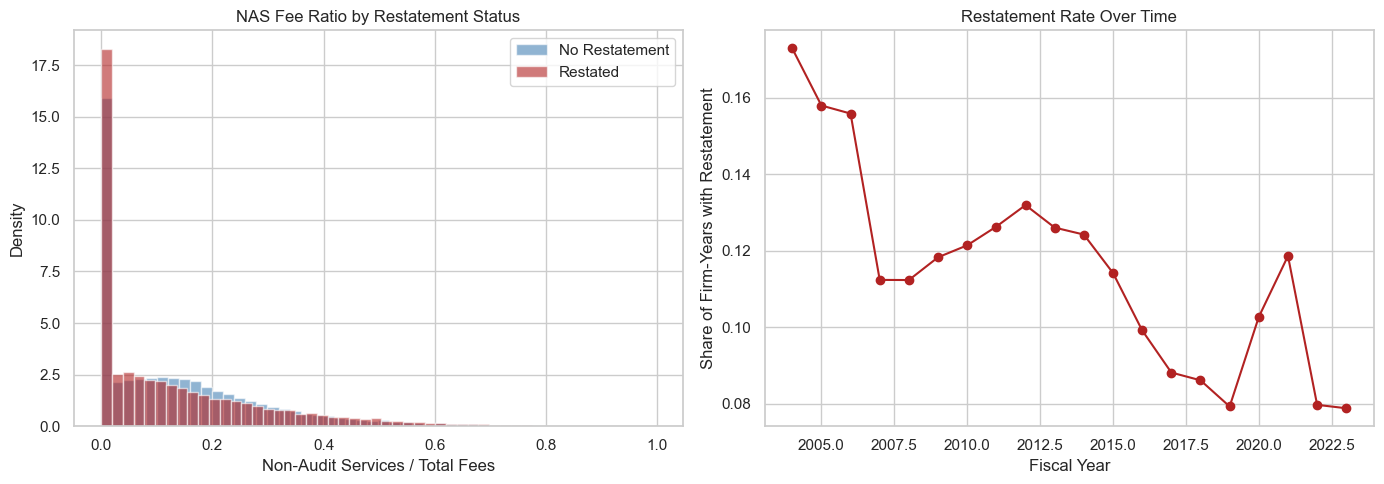

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of NAS ratio for restated vs. non-restated firms
r0 = merged[merged["restated"] == 0]["nas_ratio"]
r1 = merged[merged["restated"] == 1]["nas_ratio"]
axes[0].hist(r0, bins=50, alpha=0.6, color="steelblue", label="No Restatement", density=True)
axes[0].hist(r1, bins=50, alpha=0.6, color="firebrick", label="Restated", density=True)
axes[0].set_title("NAS Fee Ratio by Restatement Status")
axes[0].set_xlabel("Non-Audit Services / Total Fees")
axes[0].set_ylabel("Density")
axes[0].legend()

# Restatement rate over time
yearly_rate = merged.groupby("fiscal_year")["restated"].mean()
axes[1].plot(yearly_rate.index, yearly_rate.values, "o-", color="firebrick")
axes[1].set_title("Restatement Rate Over Time")
axes[1].set_xlabel("Fiscal Year")
axes[1].set_ylabel("Share of Firm-Years with Restatement")

plt.tight_layout()
plt.show()

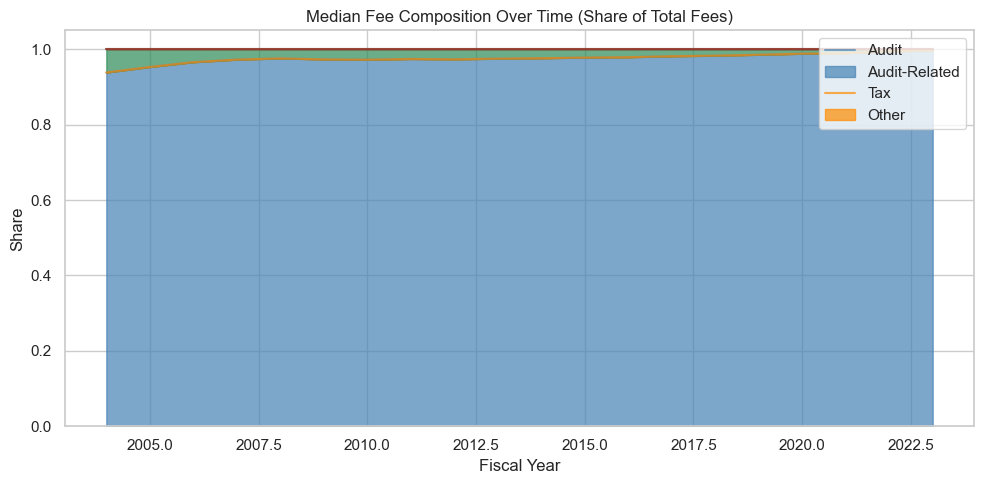

In [23]:
# Fee composition over time
yearly_fees = merged.groupby("fiscal_year")[["audit_fees", "audit_related", "tax_fees", "other_fees"]].median()
yearly_fees_share = yearly_fees.div(yearly_fees.sum(axis=1), axis=0)

yearly_fees_share.plot(kind="area", stacked=True, figsize=(10, 5),
                        color=["steelblue", "darkorange", "seagreen", "firebrick"],
                        alpha=0.7)
plt.title("Median Fee Composition Over Time (Share of Total Fees)")
plt.xlabel("Fiscal Year")
plt.ylabel("Share")
plt.legend(["Audit", "Audit-Related", "Tax", "Other"], loc="upper right")
plt.tight_layout()
plt.show()

## 6. Comparing to Kinney, Palmrose & Scholz (2004): What's the same, what's different

**What replicates cleanly**

The core data pipeline works well. Audit Analytics provides both the audit fee breakdown and the restatement events in dedicated tables that link on `company_fkey`. The fee ratio construction is identical to the paper's approach. The finding that tax service fees tend to be negatively (or insignificantly) associated with restatements, while "other" unspecified fees show a positive association, should be visible in the regression output, consistent with the paper's conclusion that not all non-audit services are equal in their effect on audit quality.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Fee data source.** Kinney et al. used a proprietary dataset of hand-collected audit fees from seven of the largest audit firms for 1995 to 2000, which pre-dates mandatory fee disclosure. Our data comes from mandatory proxy statement disclosures (required since 2003 by SEC rules), which are what Audit Analytics collects. The mandatory disclosure regime means our data is more complete but covers a different regulatory environment.

2. **Matched sample design.** The original paper uses a carefully matched sample where each restating firm is paired with a non-restating firm of similar size and industry. Our regression uses the full unmatched sample with year fixed effects, which is a simpler but less precise approach. Students can extend this by implementing propensity score matching or coarsened exact matching.

3. **Restatement definition.** The paper uses a broader definition of restatement (including both material and non-material corrections). We use Audit Analytics' `feed09_nonreliance_restatements` table, which covers only material restatements that required an 8-K Item 4.02 filing. This is a narrower and more clearly defined set of events, which is arguably cleaner but produces fewer positive observations.

4. **Post-SOX environment.** Our sample period (2004 onward) is entirely post-Sarbanes-Oxley, which banned certain categories of non-audit services (like financial information systems design). The original paper studied the pre-SOX period when these services were permitted. This means the "other" fee category in our data may contain different types of services than in the original study.

---

## References
- [Kinney, W. R., Palmrose, Z.-V. & Scholz, S. (2004). Auditor Independence, Non-Audit Services, and Restatements: Was the U.S. Government Right? *Journal of Accounting Research*, 42(3), 561–588.](https://doi.org/10.1111/j.1475-679X.2004.t01-1-00141.x)
- WRDS Audit Analytics guide: https://uufinance.github.io/data/wrds/databases/audit-analytics/
- WRDS Audit Analytics access page: https://wrds-www.wharton.upenn.edu/pages/get-data/audit-analytics/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
